# Checkpointers

checkpointer 会在每个 super-step 保存一份 graph state 的 snapshot, 并按 **thread** 组织。用 checkpointer 编译 graph, 即可启用 human-in-the-loop workflow、time travel 调试、容错执行以及对话 memory。

![Checkpoints](https://docs.langchain.com/oss/images/checkpoints.jpg)

## 为什么要用 checkpointer

以下功能需要 checkpointer:

- **Human-in-the-loop**: checkpointer 让人们能够检查、interrupt 并批准 graph 步骤, 从而支撑 [human-in-the-loop workflow](https://docs.langchain.com/oss/langgraph/interrupts)。这类 workflow 需要 checkpointer, 因为人必须能在任意时刻查看 graph 的 state, 并且在人对 state 做出更新后 graph 必须能恢复执行。示例见 [Interrupts](https://docs.langchain.com/oss/langgraph/interrupts)。
- **Memory**: checkpointer 让不同交互之间可以保留 ["memory"](https://docs.langchain.com/oss/concepts/memory)。在反复的人机交互 (如对话) 中, 任何后续消息都可以发送到该 thread, 它会保留对先前消息的 memory。关于如何用 checkpointer 添加和管理对话 memory, 见 [Add memory](https://docs.langchain.com/oss/langgraph/add-memory)。
- **Time travel**: checkpointer 支持 ["time travel"](https://docs.langchain.com/oss/langgraph/use-time-travel), 让用户可以重放先前的 graph 执行, 以审查和 / 或调试特定的 graph 步骤。此外, checkpointer 还能在任意 checkpoint 处对 graph state 进行分叉, 以探索不同的轨迹。
- **Fault-tolerance**: checkpointing 提供容错与错误恢复: 如果一个或多个 node 在某个 superstep 失败, 你可以从上一个成功的步骤重启 graph。
- **Pending writes**: 当某个 graph node 在给定的 [super-step](#super-steps) 执行到一半时失败, LangGraph 会存储该 super-step 中其他已成功完成的 node 所产生的 pending checkpoint writes。当你从该 super-step 恢复 graph 执行时, 不会重新运行那些成功的 node。

## 核心概念

### Threads

thread 是分配给 checkpointer 保存的每个 checkpoint 的唯一 ID, 即 thread identifier。它包含一串 [run](https://docs.langchain.com/langsmith/runs) 累积起来的 state。当某个 run 执行时, assistant 底层 graph 的 [state](https://docs.langchain.com/oss/langgraph/graph-api#state) 会被持久化到该 thread。

用 checkpointer 调用 graph 时, 你**必须**在 config 的 `configurable` 部分指定 `thread_id`:

```python
{"configurable": {"thread_id": "1"}}
```

thread 的当前 state 与历史 state 都可以读取。要持久化 state, 必须在执行 run 之前先创建 thread。LangSmith API 提供了多个 endpoint, 用于创建和管理 thread 及 thread state。更多细节见 [API 参考](https://reference.langchain.com/python/langsmith/)。

checkpointer 用 `thread_id` 作为存储与检索 checkpoint 的主键。没有它, checkpointer 就无法保存 state, 也无法在 [interrupt](https://docs.langchain.com/oss/langgraph/interrupts) 之后恢复执行, 因为 checkpointer 需要靠 `thread_id` 来加载已保存的 state。

In [1]:
# 环境准备: 从 .env 加载 API keys
from dotenv import load_dotenv

load_dotenv()  # 自动向上查找仓库根目录的 .env

# ---- 统一导入 ----
from operator import add
from typing import Annotated

from typing_extensions import TypedDict

from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
from IPython.display import display, Image
from langgraph.graph.state import CompiledStateGraph

def show_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))

from rich import print as rprint


### Checkpoints

thread 在某个特定时间点的 state 称为 checkpoint。checkpoint 是在每个 [super-step](#super-steps) 保存的 graph state snapshot, 由 `StateSnapshot` 对象表示 (完整字段参考见 [StateSnapshot 字段](#statesnapshot-fields))。

#### Super-steps

LangGraph 会在每个 **super-step** 边界创建一个 checkpoint。super-step 是 graph 的一次 "tick", 在该步中所有被调度的 node 都会执行 (可能并行)。对于像 `START -> A -> B -> END` 这样的顺序 graph, 输入、node A 和 node B 各自有独立的 super-step — 每完成一个就会产生一个 checkpoint。理解 super-step 边界对 [time travel](https://docs.langchain.com/oss/langgraph/use-time-travel) 很重要, 因为你只能从 checkpoint, 也就是 super-step 边界处恢复执行。

除了 super-step checkpoint 之外, LangGraph 还会在 **node (task) 级别**持久化写入。当 super-step 内的每个 node 完成时, 它的输出会以 task 条目的形式写入 checkpointer 的 `checkpoint_writes` 表, 并与进行中的 checkpoint 关联。正是这些 per-task writes 支撑了 [pending writes](#pending-writes) 恢复: 如果同一 super-step 中的另一个 node 失败, 成功 node 的写入已经持久化, 恢复时无需重新运行。super-step 完成后, 完整的 state snapshot 才会被提交。

LangGraph 还会持久化 super-step 内各个 node 执行的写入。这些写入以 task 的形式存储, 用于容错: 如果同一 super-step 中的另一个 node 失败, 恢复时无需重新计算成功 node 的写入。这些 task writes 不是完整的 `StateSnapshot` checkpoint, 因此 time travel 会从 super-step 边界处的完整 checkpoint 恢复。

checkpoint 会被持久化, 可在之后用于恢复 thread 的 state。

让我们看看按下面方式调用一个简单 graph 时会保存哪些 checkpoint:

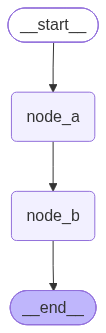

{'foo': 'b', 'bar': ['a', 'b']}

In [3]:
class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]


def node_a(state: State):
    return {"foo": "a", "bar": ["a"]}


def node_b(state: State):
    return {"foo": "b", "bar": ["b"]}


workflow = StateGraph(State)
workflow.add_node(node_a)
workflow.add_node(node_b)
workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

show_graph(graph)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}
rprint(graph.invoke({"foo": "", "bar": []}, config))

运行 graph 后, 将正好有 4 个 checkpoint:

* 空 checkpoint, 下一个要执行的 node 是 `START`
* 包含用户输入 `{'foo': '', 'bar': []}` 的 checkpoint, 下一个要执行的 node 是 `node_a`
* 包含 `node_a` 输出 `{'foo': 'a', 'bar': ['a']}` 的 checkpoint, 下一个要执行的 node 是 `node_b`
* 包含 `node_b` 输出 `{'foo': 'b', 'bar': ['a', 'b']}` 的 checkpoint, 没有下一个要执行的 node

注意 `bar` 通道的值包含两个 node 的输出, 因为这个示例为 `bar` 通道设置了 reducer。

#### Checkpoint namespace

每个 checkpoint 都有一个 `checkpoint_ns` (checkpoint namespace) 字段, 用于标识它属于哪个 graph 或 subgraph:

- **`""`** (空字符串): 该 checkpoint 属于父 (根) graph。
- **`"node_name:uuid"`**: 该 checkpoint 属于作为给定 node 被调用的 subgraph。对于嵌套 subgraph, 各 namespace 用 `|` 分隔符连接 (例如 `"outer_node:uuid|inner_node:uuid"`)。

你可以在 node 内部通过 config 访问 checkpoint namespace:

In [4]:
def my_node(state: State, config: RunnableConfig):
    checkpoint_ns = config["configurable"]["checkpoint_ns"]
    # "" for the parent graph, "node_name:uuid" for a subgraph

关于如何使用 subgraph state 与 checkpoint, 更多细节见 [Subgraphs](https://docs.langchain.com/oss/langgraph/use-subgraphs)。

## 获取并更新 state

### 获取 state

与已保存的 graph state 交互时, 你**必须**指定 [thread identifier](#threads)。你可以通过调用 `graph.get_state(config)` 查看 graph 的_最新_ state。它会返回一个 `StateSnapshot` 对象, 对应 config 中提供的 thread ID 所关联的最新 checkpoint, 或者 (如果提供了的话) 与该 thread 的某个 checkpoint ID 关联的 checkpoint。

In [5]:
# get the latest state snapshot
graph.get_state(config)

# get a state snapshot for a specific checkpoint_id
config = {"configurable": {"thread_id": "1", "checkpoint_id": "1ef663ba-28fe-6528-8002-5a559208592c"}}
rprint(graph.get_state(config))

StateSnapshot(
    values={},
    next=(),
    config={'configurable': {'thread_id': '1', 'checkpoint_id': '1ef663ba-28fe-6528-8002-5a559208592c'}},
    metadata=None,
    created_at=None,
    parent_config=None,
    tasks=(),
    interrupts=()
)

在这个示例中, `get_state` 的输出如下所示:

```
StateSnapshot(
    values={'foo': 'b', 'bar': ['a', 'b']},
    next=(),
    config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28fe-6528-8002-5a559208592c'}},
    metadata={'source': 'loop', 'writes': {'node_b': {'foo': 'b', 'bar': ['b']}}, 'step': 2},
    created_at='2024-08-29T19:19:38.821749+00:00',
    parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28f9-6ec4-8001-31981c2c39f8'}},
    tasks=()
)
```

#### StateSnapshot 字段

| 字段 | 类型 | 描述 |
|-------|------|-------------|
| `values` | `dict` | 该 checkpoint 处的 state 通道值。 |
| `next` | `tuple[str, ...]` | 接下来要执行的 node 名称。空的 `()` 表示 graph 已完成。 |
| `config` | `dict` | 包含 `thread_id`、`checkpoint_ns` 与 `checkpoint_id`。 |
| `metadata` | `dict` | 执行元数据。包含 `source` (`"input"`、`"loop"` 或 `"update"`)、`writes` (node 输出) 与 `step` (super-step 计数器)。 |
| `created_at` | `str` | 该 checkpoint 创建时间的 ISO 8601 时间戳。 |
| `parent_config` | `dict \| None` | 上一个 checkpoint 的 config。第一个 checkpoint 为 `None`。 |
| `tasks` | `tuple[PregelTask, ...]` | 该步要执行的 task。每个 task 都有 `id`、`name`、`error`、`interrupts`, 以及可选的 `state` (subgraph snapshot, 使用 `subgraphs=True` 时)。 |

### 获取 state 历史

你可以通过调用 `graph.get_state_history(config)` 获取给定 thread 的完整 graph 执行历史。它会返回一个 `StateSnapshot` 对象列表, 这些对象与 config 中提供的 thread ID 关联。重要的是, checkpoint 会按时间顺序排列, 最新的 checkpoint / `StateSnapshot` 位于列表首位。

In [6]:
config = {"configurable": {"thread_id": "1"}}
rprint(list(graph.get_state_history(config)))

[
    StateSnapshot(
        values={'foo': 'b', 'bar': ['a', 'b']},
        next=(),
        config={
            'configurable': {
                'thread_id': '1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1be171-c291-6037-8002-07588ccee79d'
            }
        },
        metadata={'source': 'loop', 'step': 2, 'parents': {}},
        created_at='2026-10-02T04:09:49.117419+00:00',
        parent_config={
            'configurable': {
                'thread_id': '1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1be171-c28c-66f2-8001-4461508cbf10'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={'foo': 'a', 'bar': ['a']},
        next=('node_b',),
        config={
            'configurable': {
                'thread_id': '1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1be171-c28c-66f2-8001-4461508cbf10'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-10-02T04:09:49.115535+00:00',
        parent_config={
            'configurable': {
                'thread_id': '1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1be171-c287-62b1-8000-c3b79f98505c'
            }
        },
        tasks=(
            PregelTask(
                id='de90ac8c-3e6e-6b58-e1a8-f9134442adb4',
                name='node_b',
                path=('__pregel_pull', 'node_b'),
                error=None,
                interrupts=(),
                state=None,
                result={'foo': 'b', 'bar': ['b']}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'foo': '', 'bar': []},
        next=('node_a',),
        config={
            'configurable': {
                'thread_id': '1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1be171-c287-62b1-8000-c3b79f98505c'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-10-02T04:09:49.113392+00:00',
        parent_config={
            'configurable': {
                'thread_id': '1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1be171-c283-6e24-bfff-4b8af3952429'
            }
        },
        tasks=(
            PregelTask(
                id='bd3f7055-0748-e466-6e0e-1cba30d4a1f5',
                name='node_a',
                path=('__pregel_pull', 'node_a'),
                error=None,
                interrupts=(),
                state=None,
                result={'foo': 'a', 'bar': ['a']}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'bar': []},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': '1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1be171-c283-6e24-bfff-4b8af3952429'
            }
        },
        metadata={'source': 'input', 'step': -1, 'parents': {}},
        created_at='2026-10-02T04:09:49.112055+00:00',
        parent_config=None,
        tasks=(
            PregelTask(
                id='0a4eb1c7-fd48-025c-f4d9-6034a30b889e',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={'foo': '', 'bar': []}
            ),
        ),
        interrupts=()
    )
]

在这个示例中, `get_state_history` 的输出如下所示:

```
[
    StateSnapshot(
        values={'foo': 'b', 'bar': ['a', 'b']},
        next=(),
        config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28fe-6528-8002-5a559208592c'}},
        metadata={'source': 'loop', 'writes': {'node_b': {'foo': 'b', 'bar': ['b']}}, 'step': 2},
        created_at='2024-08-29T19:19:38.821749+00:00',
        parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28f9-6ec4-8001-31981c2c39f8'}},
        tasks=(),
    ),
    StateSnapshot(
        values={'foo': 'a', 'bar': ['a']},
        next=('node_b',),
        config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28f9-6ec4-8001-31981c2c39f8'}},
        metadata={'source': 'loop', 'writes': {'node_a': {'foo': 'a', 'bar': ['a']}}, 'step': 1},
        created_at='2024-08-29T19:19:38.819946+00:00',
        parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28f4-6b4a-8000-ca575a13d36a'}},
        tasks=(PregelTask(id='6fb7314f-f114-5413-a1f3-d37dfe98ff44', name='node_b', error=None, interrupts=()),),
    ),
    StateSnapshot(
        values={'foo': '', 'bar': []},
        next=('node_a',),
        config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28f4-6b4a-8000-ca575a13d36a'}},
        metadata={'source': 'loop', 'writes': None, 'step': 0},
        created_at='2024-08-29T19:19:38.817813+00:00',
        parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28f0-6c66-bfff-6723431e8481'}},
        tasks=(PregelTask(id='f1b14528-5ee5-579c-949b-23ef9bfbed58', name='node_a', error=None, interrupts=()),),
    ),
    StateSnapshot(
        values={'bar': []},
        next=('__start__',),
        config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef663ba-28f0-6c66-bfff-6723431e8481'}},
        metadata={'source': 'input', 'writes': {'foo': ''}, 'step': -1},
        created_at='2024-08-29T19:19:38.816205+00:00',
        parent_config=None,
        tasks=(PregelTask(id='6d27aa2e-d72b-5504-a36f-8620e54a76dd', name='__start__', error=None, interrupts=()),),
    )
]
```

![State](https://docs.langchain.com/oss/images/get_state.jpg)

#### 查找特定的 checkpoint

你可以筛选 state 历史, 找出符合特定条件的 checkpoint:

```python
history = list(graph.get_state_history(config))

# Find the checkpoint before a specific node executed
before_node_b = next(s for s in history if s.next == ("node_b",))

# Find a checkpoint by step number
step_2 = next(s for s in history if s.metadata["step"] == 2)

# Find checkpoints created by update_state
forks = [s for s in history if s.metadata["source"] == "update"]

# Find the checkpoint where an interrupt occurred
interrupted = next(
    s for s in history
    if s.tasks and any(t.interrupts for t in s.tasks)
)
```

### 重放

重放会从先前的 checkpoint 重新执行步骤。用先前的 `checkpoint_id` 调用 graph, 即可重新运行该 checkpoint 之后的 node。checkpoint 之前的 node 会被跳过 (它们的结果已经保存)。checkpoint 之后的 node 会重新执行, 包括任何 LLM 调用、API 请求或 [interrupt](https://docs.langchain.com/oss/langgraph/interrupts) — 在重放期间它们总会被重新触发。

关于重放先前执行的完整细节与代码示例, 见 [Time travel](https://docs.langchain.com/oss/langgraph/use-time-travel)。

![Replay](https://docs.langchain.com/oss/images/re_play.png)

### 更新 state

你可以用 `update_state` 编辑 graph state。它会用更新后的值创建一个新 checkpoint — 不会修改原始 checkpoint。该更新的处理方式与 node 更新相同: 如果定义了 [reducer](https://docs.langchain.com/oss/langgraph/graph-api#reducers) 函数, 值会经过它们处理, 因此带 reducer 的通道会_累积_值, 而不是覆盖。

你可以选择指定 `as_node` 来控制该更新被视为来自哪个 node, 这会影响接下来哪个 node 执行。细节见 [Time travel: `as_node`](https://docs.langchain.com/oss/langgraph/use-time-travel#from-a-specific-node)。

![Update](https://docs.langchain.com/oss/images/checkpoints_full_story.jpg)

## 持久性模式

LangGraph 支持三种持久性模式, 让你在性能与数据一致性之间取得平衡。你可以在调用任何 graph 执行方法时指定持久性模式:

```python
graph.stream(
    {"input": "test"},
    durability="sync"
)
```

持久性模式按持久性从低到高排列如下:

* `"exit"`: LangGraph 仅在 graph 执行退出时持久化变更 — 无论是成功、出错, 还是因 human-in-the-loop interrupt。这为长时运行的 graph 提供了最佳性能, 但意味着中间 state 不会被保存, 因此你无法在执行中途从系统故障 (如进程崩溃) 中恢复。
* `"async"`: LangGraph 会在下一步执行时以 async 方式持久化变更。这提供了良好的性能与持久性, 但如果进程在执行期间崩溃, LangGraph 有很小的可能不会写入 checkpoint。
* `"sync"`: LangGraph 会在下一步开始前同步持久化变更。这确保 LangGraph 在继续执行之前写入每一个 checkpoint, 从而以一定的性能开销换来高持久性。

## 优化 checkpoint 存储

默认情况下, LangGraph checkpoint 会在每个 super-step 写入每个 state 通道的完整值。对于会大量累积的长时运行 thread — 例如多轮对话 — 这可能导致存储随时间显著增长。

`DeltaChannel` 只存储增量 delta, 而不是完整的累积值, 对以追加为主的通道能大幅减小 checkpoint 体积。用法以及存储与延迟之间的权衡, 见 [DeltaChannel](https://docs.langchain.com/oss/langgraph/pregel#deltachannel)。

> **警告**
>
> `DeltaChannel` 需要 `langgraph>=1.2`, 目前处于 beta。该 API 在未来版本中可能发生变化。

## Checkpointer 库

在底层, checkpointing 由符合 `BaseCheckpointSaver` 接口的 checkpointer 对象驱动。LangGraph 提供了多种 checkpointer 实现, 它们都通过独立、可安装的库实现。

> **注意**
>
> 可用的 provider 见 [checkpointer 集成](https://docs.langchain.com/oss/integrations/checkpointers/index)。

* `langgraph-checkpoint`: checkpointer saver 的基础接口 (`BaseCheckpointSaver`) 以及序列化/反序列化接口 (`SerializerProtocol`)。包含用于实验的内存 checkpointer 实现 (`InMemorySaver`)。LangGraph 自带 `langgraph-checkpoint`。
* `langgraph-checkpoint-sqlite`: 使用 SQLite 数据库的 LangGraph checkpointer 实现 (`SqliteSaver` / `AsyncSqliteSaver`)。适合实验与本地 workflow。需要单独安装。
* `langgraph-checkpoint-postgres`: 使用 Postgres 数据库的高级 checkpointer (`PostgresSaver` / `AsyncPostgresSaver`), 用于 LangSmith。适合在生产环境使用。需要单独安装。
* `langgraph-checkpoint-mongodb`: 使用 MongoDB 的高级 checkpointer (`MongoDBSaver` / `AsyncMongoDBSaver`)。适合在生产环境使用。需要单独安装。
* `langchain-azure-cosmosdb`: 使用 Azure Cosmos DB for NoSQL 的 LangGraph checkpointer 实现 (`CosmosDBSaverSync` / `CosmosDBSaver`)。适合在 Azure 上的生产环境使用。同时支持同步与 async 操作, 并使用 Microsoft Entra ID 认证。需要单独安装。

### Checkpointer 接口

每个 checkpointer 都符合 `BaseCheckpointSaver` 接口, 并实现以下方法:

* `.put` - 存储一个 checkpoint 及其 config 与 metadata。
* `.put_writes` - 存储与某个 checkpoint 关联的中间写入 (即 [pending writes](#pending-writes))。
* `.get_tuple` - 根据给定 config (`thread_id` 与 `checkpoint_id`) 获取 checkpoint tuple。它用于填充 `graph.get_state()` 中的 `StateSnapshot`。
* `.list` - 列出匹配给定 config 与筛选条件的 checkpoint。它用于填充 `graph.get_state_history()` 中的 state 历史。

如果 checkpointer 与 async graph 执行一起使用 (即通过 `.ainvoke`、`.astream`、`.abatch` 执行 graph), 则会使用上述方法的 async 版本 (`.aput`、`.aput_writes`、`.aget_tuple`、`.alist`)。

> **注意**
>
> 若要 async 地运行 graph, 你可以使用 `InMemorySaver`, 或 Sqlite/Postgres checkpointer 的 async 版本 -- `AsyncSqliteSaver` / `AsyncPostgresSaver` checkpointer。

### Serializer

checkpointer 保存 graph state 时, 需要序列化 state 中的通道值。这通过 serializer 对象完成。

`langgraph_checkpoint` 定义了用于实现 serializer 的 `protocol`, 并提供了默认实现 (`JsonPlusSerializer`), 它能处理多种类型, 包括 LangChain 与 LangGraph 的原语、datetime、enum 等。

#### 用 `pickle` 序列化

默认 serializer `JsonPlusSerializer` 在底层使用 ormsgpack 与 JSON, 这并不适合所有类型的对象。

如果你希望对 msgpack 编码器当前不支持的对象 (例如 Pandas dataframe) 回退到 pickle, 可以使用 `JsonPlusSerializer` 的 `pickle_fallback` 参数:

```python
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer

# ... Define the graph ...
graph.compile(
    checkpointer=InMemorySaver(serde=JsonPlusSerializer(pickle_fallback=True))
)
```

#### 加密

checkpointer 可以选择加密所有持久化的 state。要启用它, 请把 `EncryptedSerializer` 实例传入任何 `BaseCheckpointSaver` 实现的 `serde` 参数。创建加密 serializer 最简单的方式是通过 `from_pycryptodome_aes`, 它会从 `LANGGRAPH_AES_KEY` 环境变量读取 AES key (或接受 `key` 参数):

```python
import sqlite3

from langgraph.checkpoint.serde.encrypted import EncryptedSerializer
from langgraph.checkpoint.sqlite import SqliteSaver

serde = EncryptedSerializer.from_pycryptodome_aes()  # reads LANGGRAPH_AES_KEY
checkpointer = SqliteSaver(sqlite3.connect("checkpoint.db"), serde=serde)
```

```python
from langgraph.checkpoint.serde.encrypted import EncryptedSerializer
from langgraph.checkpoint.postgres import PostgresSaver

serde = EncryptedSerializer.from_pycryptodome_aes()
checkpointer = PostgresSaver.from_conn_string("postgresql://...", serde=serde)
checkpointer.setup()
```

在 LangSmith 上运行时, 只要存在 `LANGGRAPH_AES_KEY`, 加密就会自动启用, 因此你只需提供该环境变量。通过实现 `CipherProtocol` 并将其提供给 `EncryptedSerializer`, 还可以使用其他加密方案。

## 构建自定义 checkpointer

> **提示**
>
> 在构建过程中, 使用[一致性测试套件](#testing-with-the-conformance-suite)验证你的实现。它涵盖了全部五个基础方法以及包括 delta channel 在内的扩展能力。在发布前请在 CI 中运行它。

本节介绍如何为自定义存储 backend 从零实现 `BaseCheckpointSaver`。如果你已经有一个可用的 checkpointer, 只想添加 delta channel 支持, 请跳到 [Delta channel support](#delta-channel-support)。

### 概览

LangGraph 的 persistence 层建立在两个存储抽象之上:

- **Checkpoints 表** — 每个 superstep 一行; 存储序列化后的 graph state (`channel_values`、`channel_versions`、`versions_seen`), 并链接到其父 checkpoint。
- **Writes 表** — superstep 内每个 node 输出一行; 存储与某个 checkpoint 关联的 `(task_id, channel, value)` tuple。

你的 checkpointer 管理这两张表。`put` 写入一行 checkpoint; `put_writes` 写入 node 输出行; `get_tuple` 把两者读回为一个 `CheckpointTuple`。

### 基础契约

继承 `BaseCheckpointSaver` 并实现以下五个方法。它们都是必需的 — 缺少任何一个基础方法都会在 runtime 抛出 `NotImplementedError`。

```python
from collections.abc import AsyncIterator, Iterator, Sequence
from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.base import (
    BaseCheckpointSaver,
    ChannelVersions,
    Checkpoint,
    CheckpointMetadata,
    CheckpointTuple,
)

class MyCheckpointer(BaseCheckpointSaver):
    async def aput(
        self,
        config: RunnableConfig,
        checkpoint: Checkpoint,
        metadata: CheckpointMetadata,
        new_versions: ChannelVersions,
    ) -> RunnableConfig:
        ...

    async def aput_writes(
        self,
        config: RunnableConfig,
        writes: Sequence[tuple[str, Any]],
        task_id: str,
        task_path: str = "",
    ) -> None:
        ...

    async def aget_tuple(self, config: RunnableConfig) -> CheckpointTuple | None:
        ...

    async def alist(
        self,
        config: RunnableConfig | None,
        *,
        filter: dict[str, Any] | None = None,
        before: RunnableConfig | None = None,
        limit: int | None = None,
    ) -> AsyncIterator[CheckpointTuple]:
        ...
        yield  # make this an async generator

    async def adelete_thread(self, thread_id: str) -> None:
        ...
```

#### put / aput

存储一行 checkpoint。返回带有已存储 `checkpoint_id` 的更新后 config。

关键要求:

- 使用 `self.serde.dumps_typed(checkpoint)` 序列化 checkpoint — 它会处理所有 LangGraph 原生类型, 包括 delta channel 使用的 `_DeltaSnapshot` blob。
- 完整存储 `metadata` — 不要剔除未知键。LangGraph 会在小版本中新增 metadata 字段 (例如 delta channel 的 `counters_since_delta_snapshot`); 丢弃它们会在无声无息中破坏功能。
- 将 `config["configurable"].get("checkpoint_id")` 存储为父 checkpoint ID, 以便 `get_tuple` 填充 `parent_config`。

```python
async def aput(self, config, checkpoint, metadata, new_versions):
    thread_id = config["configurable"]["thread_id"]
    checkpoint_ns = config["configurable"]["checkpoint_ns"]
    checkpoint_id = checkpoint["id"]
    parent_id = config["configurable"].get("checkpoint_id")

    type_, blob = self.serde.dumps_typed(checkpoint)
    serialized_metadata = self.serde.dumps_typed(metadata)

    await self.db.execute(
        "INSERT INTO checkpoints (...) VALUES (...)",
        thread_id, checkpoint_ns, checkpoint_id, parent_id,
        type_, blob, *serialized_metadata,
    )
    return {
        "configurable": {
            "thread_id": thread_id,
            "checkpoint_ns": checkpoint_ns,
            "checkpoint_id": checkpoint_id,
        }
    }
```

#### put_writes / aput_writes

为当前 superstep 内的单个 task 存储 node 输出行。这些行通过 `(thread_id, checkpoint_ns, checkpoint_id)` 与 checkpoint 关联。

```python
async def aput_writes(self, config, writes, task_id, task_path=""):
    thread_id = config["configurable"]["thread_id"]
    checkpoint_ns = config["configurable"]["checkpoint_ns"]
    checkpoint_id = config["configurable"]["checkpoint_id"]

    rows = []
    for idx, (channel, value) in enumerate(writes):
        type_, blob = self.serde.dumps_typed(value)
        final_idx = WRITES_IDX_MAP.get(channel, idx)
        rows.append((thread_id, checkpoint_ns, checkpoint_id,
                      task_id, task_path, final_idx, channel, type_, blob))

    await self.db.executemany("INSERT INTO writes (...) VALUES (...)", rows)
```

从 `langgraph.checkpoint.base` 导入 `WRITES_IDX_MAP`。它把特殊通道 (`__error__`、`__interrupt__` 等) 映射到预留的负索引, 以免与常规写入索引冲突。

#### get_tuple / aget_tuple

获取一个 checkpoint。config 可能包含:

- **没有 `checkpoint_id`** — 返回 thread + namespace 的最新 checkpoint。
- **指定了某个 `checkpoint_id`** — 返回那个确切的 checkpoint。

**两条路径都必须正确工作。** 指定 id 的路径用于 time travel, 并且 — 至关重要地 — 用于每次 graph 调用时的 delta channel state 重建 (见 [Delta channel support](#delta-channel-support))。被破坏的 specific-id 查找会在无声无息中损坏 delta channel state。

```python
async def aget_tuple(self, config):
    thread_id = config["configurable"]["thread_id"]
    checkpoint_ns = config["configurable"].get("checkpoint_ns", "")
    checkpoint_id = config["configurable"].get("checkpoint_id")

    if checkpoint_id:
        row = await self.db.fetchone(
            "SELECT * FROM checkpoints "
            "WHERE thread_id=? AND checkpoint_ns=? AND checkpoint_id=?",
            thread_id, checkpoint_ns, checkpoint_id,
        )
    else:
        row = await self.db.fetchone(
            "SELECT * FROM checkpoints "
            "WHERE thread_id=? AND checkpoint_ns=? "
            "ORDER BY checkpoint_id DESC LIMIT 1",
            thread_id, checkpoint_ns,
        )

    if row is None:
        return None

    writes = await self.db.fetchall(
        "SELECT task_id, channel, type, value FROM writes "
        "WHERE thread_id=? AND checkpoint_ns=? AND checkpoint_id=? "
        "ORDER BY task_id, idx",
        thread_id, checkpoint_ns, row["checkpoint_id"],
    )
    pending_writes = [
        (w["task_id"], w["channel"], self.serde.loads_typed((w["type"], w["value"])))
        for w in writes
    ]

    checkpoint = self.serde.loads_typed((row["type"], row["blob"]))
    metadata = self.serde.loads_typed((row["metadata_type"], row["metadata"]))

    parent_config = None
    if row["parent_checkpoint_id"]:
        parent_config = {
            "configurable": {
                "thread_id": thread_id,
                "checkpoint_ns": checkpoint_ns,
                "checkpoint_id": row["parent_checkpoint_id"],
            }
        }

    return CheckpointTuple(
        config={
            "configurable": {
                "thread_id": thread_id,
                "checkpoint_ns": checkpoint_ns,
                "checkpoint_id": row["checkpoint_id"],
            }
        },
        checkpoint=checkpoint,
        metadata=metadata,
        parent_config=parent_config,
        pending_writes=pending_writes,
    )
```

> **警告**
>
> **行键 / 索引设计对 specific-id 查找至关重要。** 如果你的存储使用按时间排序的键 (例如反转的时间戳), 而其中并未嵌入 `checkpoint_id`, 那么你就无法按 id 直接读取行。你必须在行键中编码 `checkpoint_id`, 或者构建二级索引。每次查找都对值做扫描虽然可行, 但无法扩展。

#### list / alist

返回某个 thread 的 checkpoint, 最新的在前。要遵循 `before` (只返回比该 config 的 `checkpoint_id` 更早的 checkpoint) 与 `limit`。

#### delete_thread / adelete_thread

删除某个 thread 的所有 checkpoint 与写入。checkpoint 行与 write 行都必须删除。

### 行键 / 索引设计

你如何存储与索引 checkpoint, 直接影响正确性与性能。

**推荐模式 (SQL):**

```sql
CREATE TABLE checkpoints (
    thread_id          TEXT NOT NULL,
    checkpoint_ns      TEXT NOT NULL DEFAULT '',
    checkpoint_id      TEXT NOT NULL,   -- ULID, lexicographically sortable newest-last
    parent_checkpoint_id TEXT,
    type               TEXT,
    checkpoint         BYTEA,
    metadata           JSONB,
    PRIMARY KEY (thread_id, checkpoint_ns, checkpoint_id)
);

CREATE TABLE writes (
    thread_id     TEXT NOT NULL,
    checkpoint_ns TEXT NOT NULL DEFAULT '',
    checkpoint_id TEXT NOT NULL,
    task_id       TEXT NOT NULL,
    task_path     TEXT NOT NULL DEFAULT '',
    idx           INTEGER NOT NULL,
    channel       TEXT NOT NULL,
    type          TEXT,
    value         BYTEA,
    PRIMARY KEY (thread_id, checkpoint_ns, checkpoint_id, task_id, task_path, idx)
);
```

由于 `checkpoint_id` 是 ULID, 它按字典序排序 — 值越大越新。"Get latest" 是 `ORDER BY checkpoint_id DESC LIMIT 1`; "get by id" 则是对主键的等值查找。

**对于非 SQL 存储:** 同样的原则适用。无论你使用什么键方案, 按 `(thread_id, checkpoint_ns, checkpoint_id)` 的直接查找必须是 O(1) 或接近 O(1)。要避免那种只能通过扫描某个 thread 的所有行来按 id 找到 checkpoint 的设计。

### 序列化

对 checkpoint、write 与 metadata 始终使用 `self.serde` (继承自 `BaseCheckpointSaver`, 默认为 `JsonPlusSerializer`)。不要直接对 metadata 使用 `pickle` — 它能用, 但 `JsonPlusSerializer` 生成的输出可读性更好, 且对版本管理处理得更好。

`JsonPlusSerializer` 会自动处理所有 LangGraph 原生类型:
- `_DeltaSnapshot` — delta channel 使用的哨兵 blob (msgpack 扩展码 7)
- Pydantic v2 模型、dataclass、numpy 数组、datetime、enum 等

如果你编写自定义 serializer, 请确保它能对来自 `langgraph.checkpoint.serde.types` 的 `_DeltaSnapshot` 进行往返 (round-trip) 处理。

### 扩展能力

这些方法是可选的, 但能解锁额外的 Agent Server 功能。如果你的存储 backend 能高效支持它们, 就实现它们。

| 方法 | 启用的功能 |
|---|---|
| `adelete_for_runs` | 回滚多任务策略 |
| `acopy_thread` | 高效的 thread 分叉 |
| `aprune` | thread 历史裁剪 |
| `aget_delta_channel_history` | 高效的 delta channel state 重建 (见下文) |

Agent Server 会在启动时自动检测你的 checkpointer 实现了哪些能力, 并激活相应的功能。

### Delta channel support

> **注意**
>
> **DeltaChannel 处于 beta。** 在设计稳定之前, API 与磁盘上的表示形式可能发生变化。

`DeltaChannel` 是一种 reducer 通道, 它在 checkpoint blob 中只存储一个哨兵 (`MISSING`), 而不是完整的通道值。state 通过将祖先写入经由 reducer 重放来重建。这使得对于像 `messages` 这种会随时间累积的通道, checkpoint blob 每步为 O(1), 而不是 O(N)。

#### runtime 需要什么

在加载某个 checkpoint, 而其 delta channel 不在 `channel_values` 中时, LangGraph 会调用 `saver.get_delta_channel_history(config=config, channels=[...])`。它针对每个通道返回:

- **`writes`** — 祖先链中对该通道的所有写入, 最早的在前, 直到最近的 snapshot。
- **`seed`** (可选) — 最近的拥有 `_DeltaSnapshot` blob 的祖先处所存储的该 blob; 如果向上遍历到达根节点仍未找到 snapshot, 则不存在。

随后 runtime 会调用 `channel.from_checkpoint(seed)` 与 `channel.replay_writes(writes)` 来重建当前值。

#### 默认实现

`BaseCheckpointSaver` 提供了一个默认的 `get_delta_channel_history`, 它可与任何正确的 `get_tuple` 实现配合使用:

```python
# Simplified from BaseCheckpointSaver
def get_delta_channel_history(self, *, config, channels):
    target = self.get_tuple(config)          # load the head checkpoint
    cursor = target.parent_config            # walk from its parent
    collected = {ch: [] for ch in channels}
    seed = {}
    remaining = set(channels)

    while cursor and remaining:
        tup = self.get_tuple(cursor)         # ← requires correct by-id lookup
        if tup is None:
            break
        for write in reversed(tup.pending_writes or []):
            if write[1] in remaining:
                collected[write[1]].append(write)
        for ch in list(remaining):
            if ch in tup.checkpoint["channel_values"]:
                seed[ch] = tup.checkpoint["channel_values"][ch]
                remaining.discard(ch)
        cursor = tup.parent_config

    return {
        ch: {"writes": list(reversed(collected[ch])), **({"seed": seed[ch]} if ch in seed else {})}
        for ch in channels
    }
```

**关键依赖:** `get_tuple(cursor)` 总是以特定的 `checkpoint_id` (父级的 id) 被调用。如果该查找返回 `None`, 遍历会立即停止, 并且每个 delta channel 都会被重建为空 — 静默地、不报任何错误。这就是为什么 `get_tuple` 中 specific-id 路径必须正确。

#### 性能覆写

默认遍历会针对每个祖先 checkpoint 发起一次 `get_tuple` 调用。对于查询支持良好的 backend, 可以覆写 `get_delta_channel_history` (及其 async 版) 以通过两次查询获取祖先链与写入:

```python
async def aget_delta_channel_history(self, *, config, channels):
    if not channels:
        return {}

    thread_id = config["configurable"]["thread_id"]
    checkpoint_ns = config["configurable"].get("checkpoint_ns", "")
    checkpoint_id = config["configurable"]["checkpoint_id"]

    # Stage 1: stream ancestors newest-first until every channel has a seed
    ancestors = await self.db.fetchall(
        "SELECT checkpoint_id, parent_checkpoint_id, type, checkpoint "
        "FROM checkpoints "
        "WHERE thread_id=? AND checkpoint_ns=? AND checkpoint_id < ? "
        "ORDER BY checkpoint_id DESC",
        thread_id, checkpoint_ns, checkpoint_id,
    )

    chain_by_ch: dict[str, list[str]] = {ch: [] for ch in channels}
    seed_by_ch: dict[str, Any] = {}
    remaining = set(channels)
    cur_id = config["configurable"]["checkpoint_id"]

    for row in ancestors:
        if not remaining:
            break
        parent_id = row["parent_checkpoint_id"]
        ckpt = self.serde.loads_typed((row["type"], row["checkpoint"]))
        cv = ckpt.get("channel_values") or {}
        for ch in list(remaining):
            chain_by_ch[ch].append(row["checkpoint_id"])
            if ch in cv:
                seed_by_ch[ch] = cv[ch]
                remaining.discard(ch)
        cur_id = parent_id

    # Stage 2: fetch writes for each channel's ancestor chain in one query
    result: dict[str, DeltaChannelHistory] = {}
    for ch in channels:
        chain = chain_by_ch[ch]
        if not chain:
            entry: DeltaChannelHistory = {"writes": []}
            if ch in seed_by_ch:
                entry["seed"] = seed_by_ch[ch]
            result[ch] = entry
            continue

        write_rows = await self.db.fetchall(
            f"SELECT checkpoint_id, task_id, idx, type, value FROM writes "
            f"WHERE thread_id=? AND checkpoint_ns=? AND channel=? "
            f"AND checkpoint_id IN ({','.join('?' * len(chain))})"
            f"ORDER BY checkpoint_id, task_id, idx",
            thread_id, checkpoint_ns, ch, *chain,
        )
        writes_by_cid: dict[str, list[PendingWrite]] = {}
        for row in write_rows:
            cid = row["checkpoint_id"]
            value = self.serde.loads_typed((row["type"], row["value"]))
            writes_by_cid.setdefault(cid, []).append((row["task_id"], ch, value))

        # chain is newest-first; iterate oldest-first to get correct replay order
        collected: list[PendingWrite] = []
        for cid in reversed(chain):
            collected.extend(writes_by_cid.get(cid, []))

        entry = {"writes": collected}
        if ch in seed_by_ch:
            entry["seed"] = seed_by_ch[ch]
        result[ch] = entry

    return result
```

#### 带 delta channel 的裁剪

`DeltaChannel` state 并不自包含于单个 checkpoint 之中 — 它依赖于回溯到最近 `_DeltaSnapshot` 的祖先写入链。如果你实现 `prune` 或 `delete_for_runs`, 就绝不能删除某个存留 checkpoint 的 delta channel 所依赖的 write 行。

安全选项:

1. **裁剪前先遍历** — 对每个你打算保留的 checkpoint, 遍历其祖先链, 并把直到最近 `_DeltaSnapshot` 的所有 write 行标记为不可删除。
2. **裁剪前强制生成 snapshot** — 在你保留的 checkpoint 上重写 `channel_values[ch] = _DeltaSnapshot(reconstructed_value)`, 然后就可以随意删除祖先。
3. **对 delta-channel thread 跳过裁剪** — 如果你尚不需要裁剪, 这是最安全的短期选项。

#### 带 delta channel 复制 thread

实现 `copy_thread` 时, 要复制完整的祖先链 — 而不仅仅是头部 checkpoint。目标 thread 必须为每个 delta channel 都拥有回溯到至少一个 `_DeltaSnapshot` 的 write 行, 否则这些通道在复制后会重建为空。

### 用一致性测试套件测试

`langgraph-checkpoint-conformance` 会对照完整契约验证你的实现, 包括 delta channel 历史:

```python
pip install langgraph-checkpoint-conformance
```

```python
import asyncio
from langgraph.checkpoint.conformance import checkpointer_test, validate

@checkpointer_test(name="MyCheckpointer")
async def my_checkpointer():
    async with MyCheckpointer.create() as saver:
        yield saver

async def main():
    report = await validate(my_checkpointer)
    report.print_report()
    # Fails the process if any base capability is missing or broken
    if not report.passed_all_base():
        raise RuntimeError("Checkpointer failed conformance suite")

asyncio.run(main())
```

该套件会自动检测你的 checkpointer 实现了哪些扩展能力 (包括 `aget_delta_channel_history`), 并对每项运行相关测试。在发布前把它作为 CI 的一部分运行。